STUDENT PERFORMANCE DATA ANALYSIS

Dataset loaded successfully!

1. DATASET OVERVIEW

First 5 rows:
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_leve

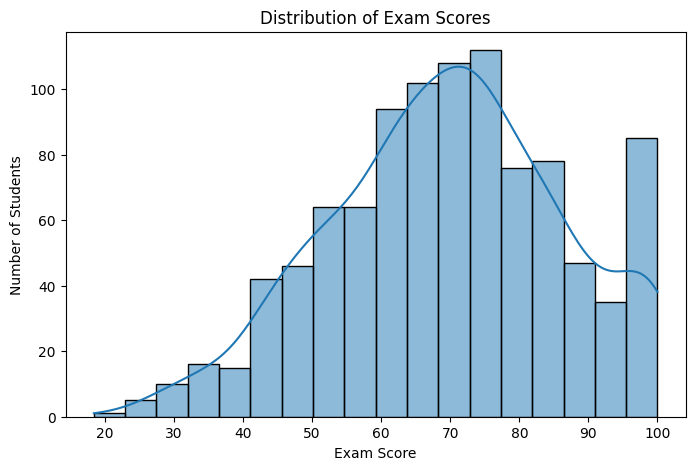

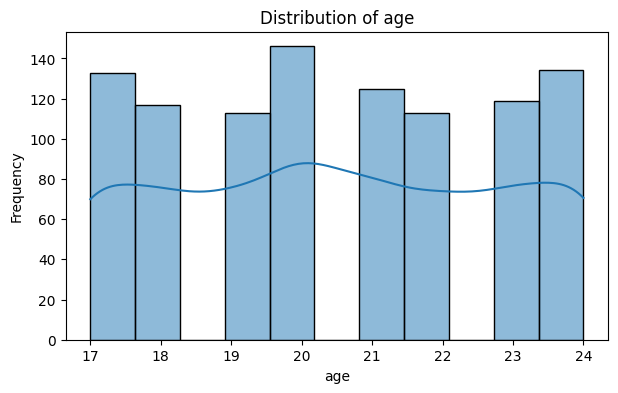

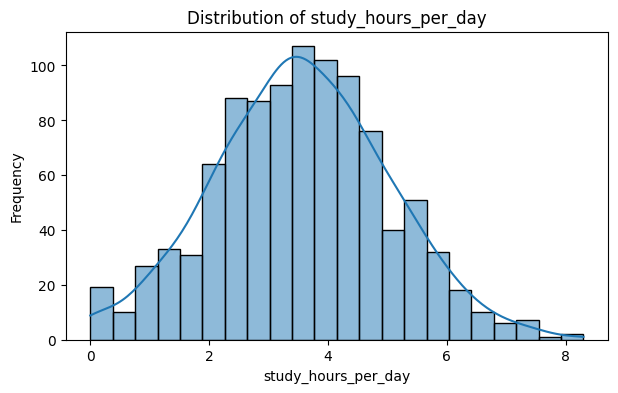

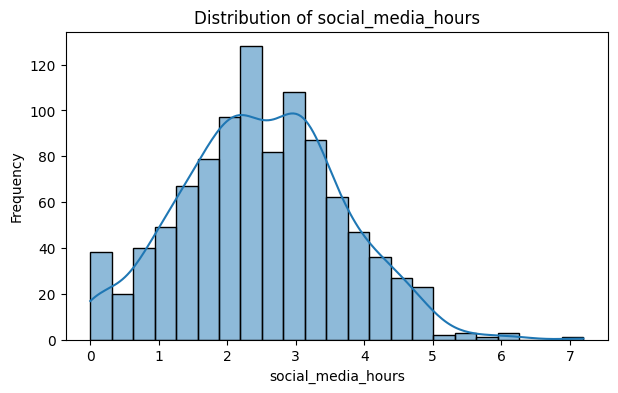

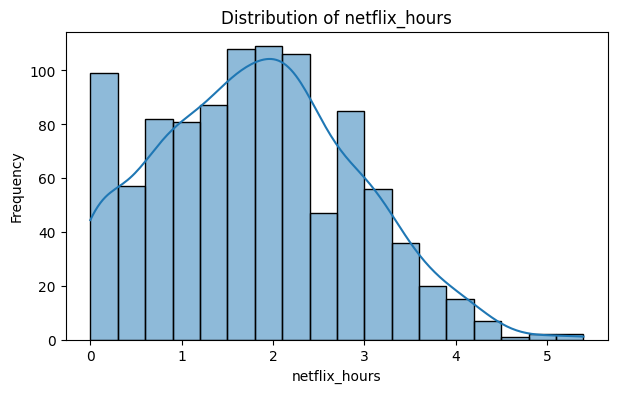

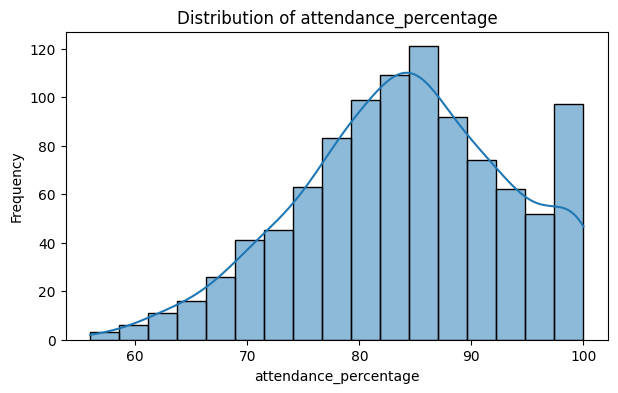

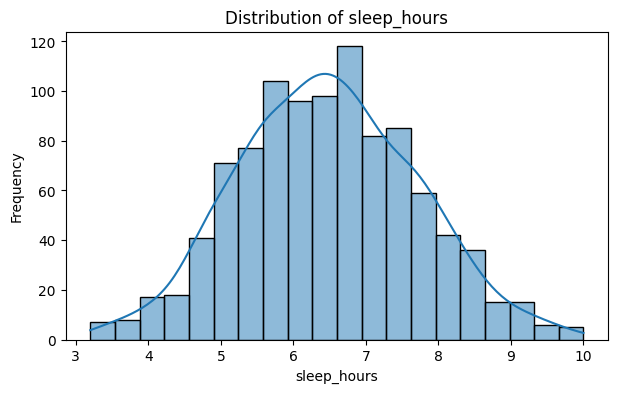

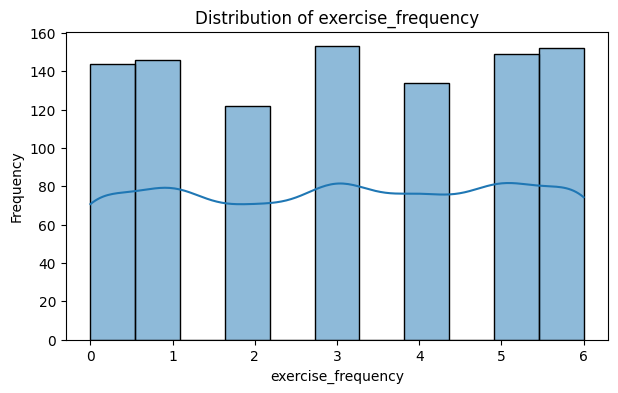

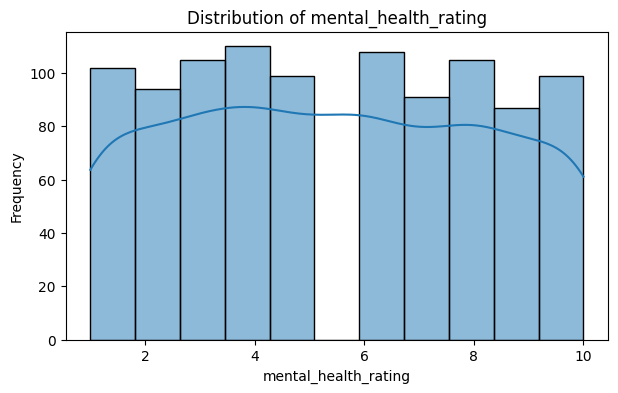

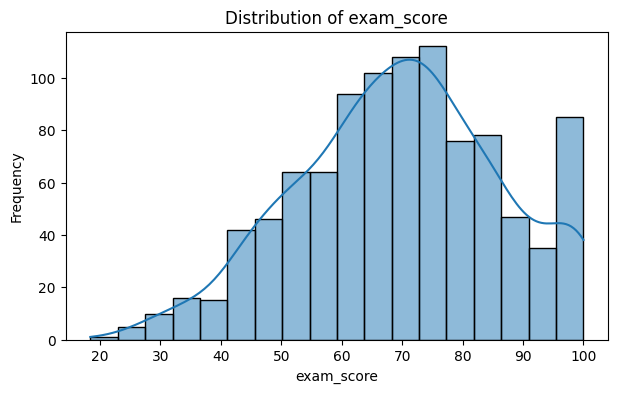

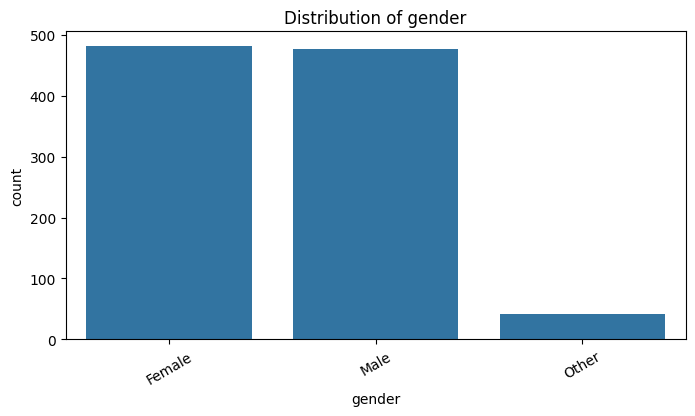

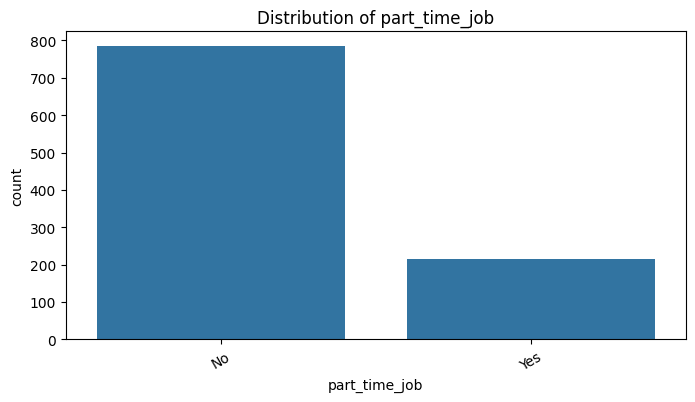

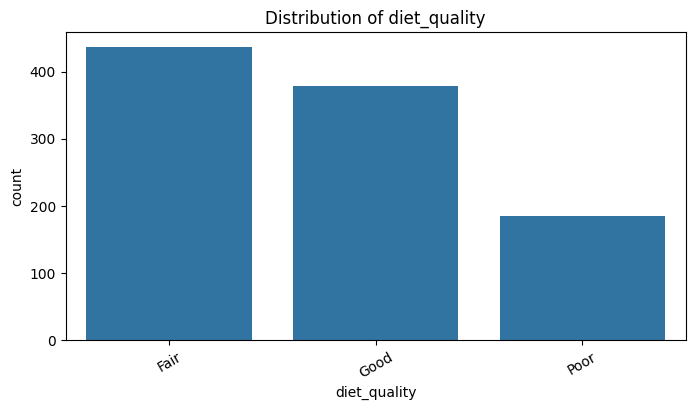

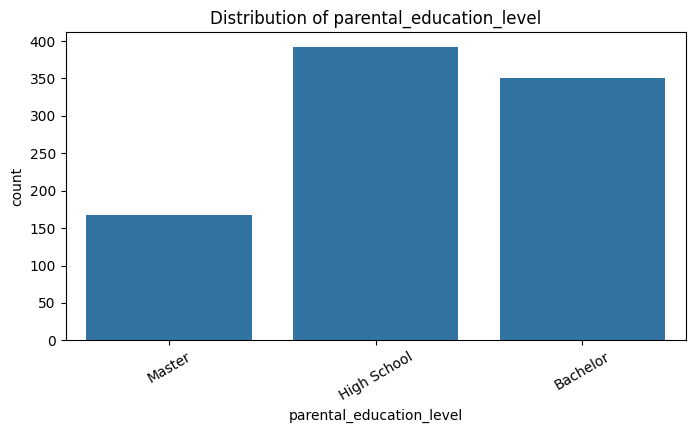

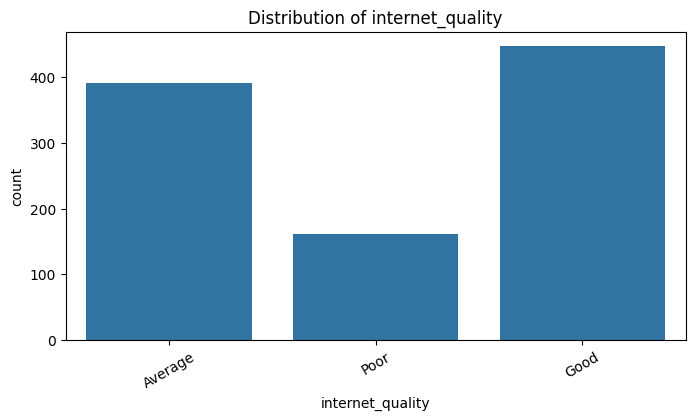

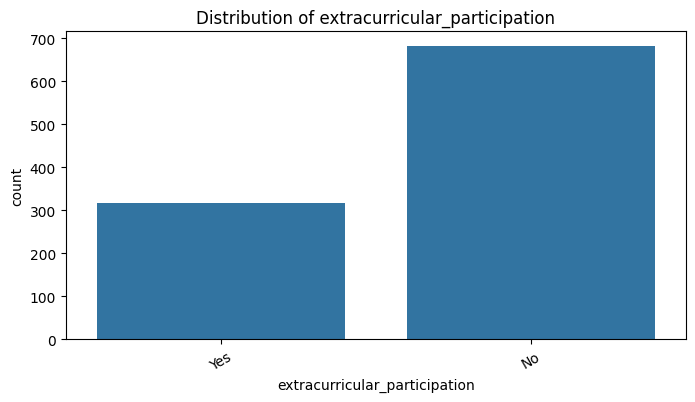


7. CORRELATION ANALYSIS

Correlation with Exam Score:
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


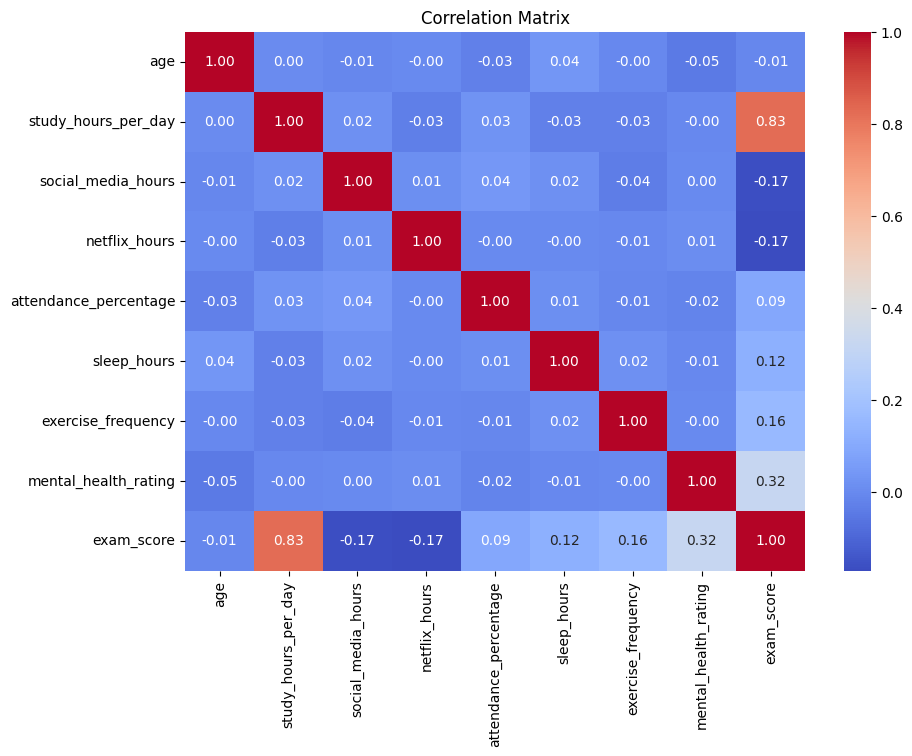

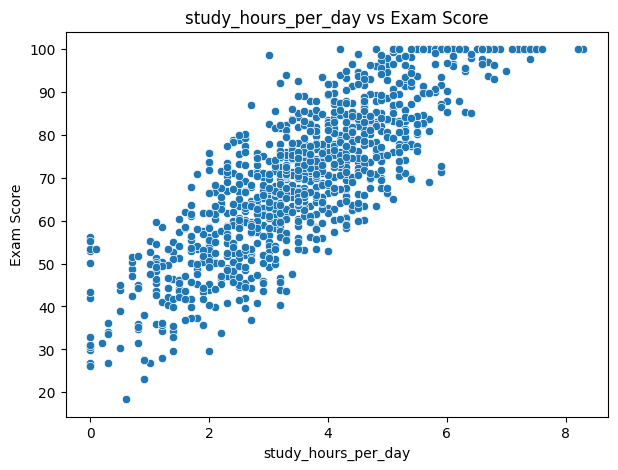

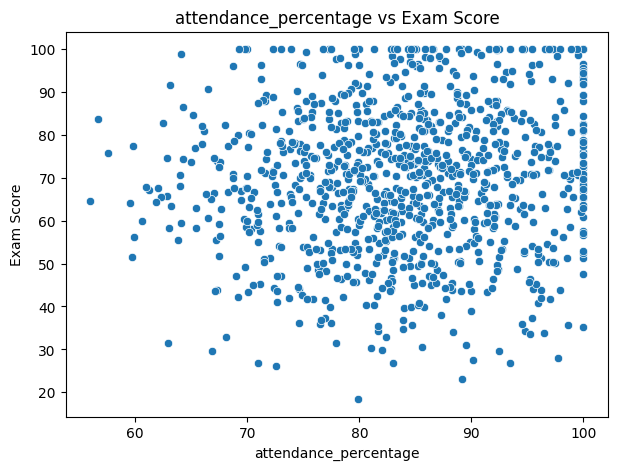

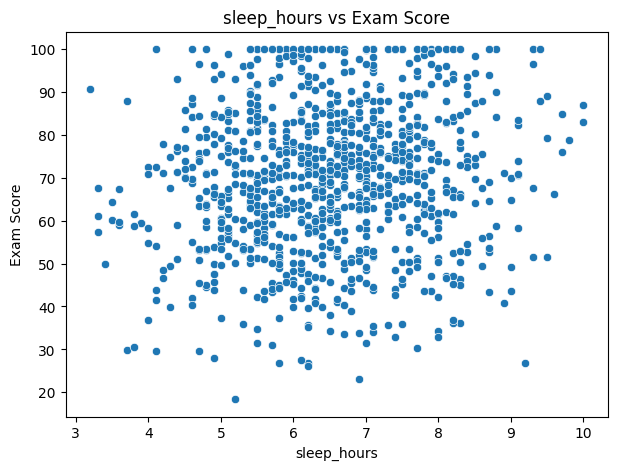

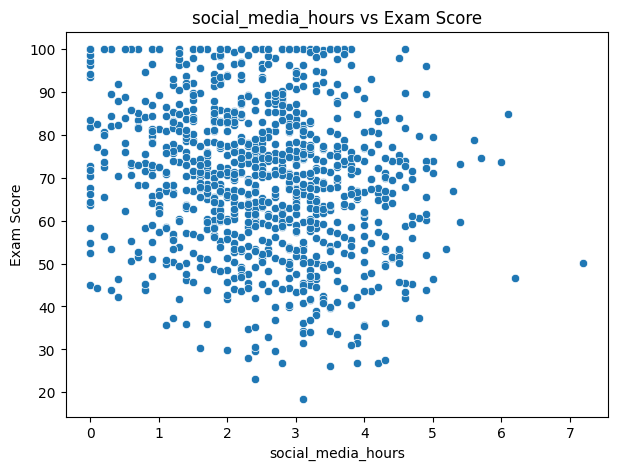

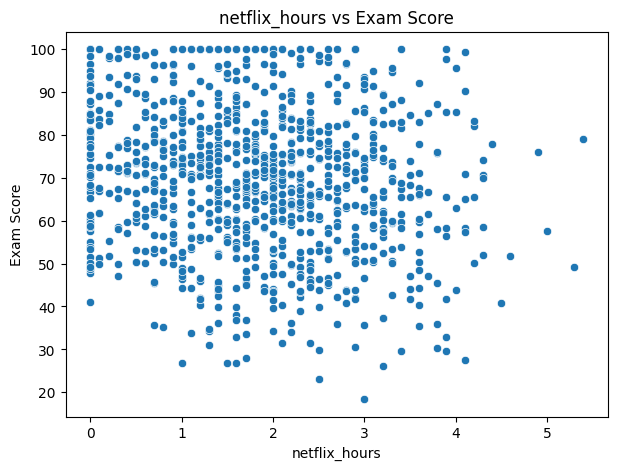

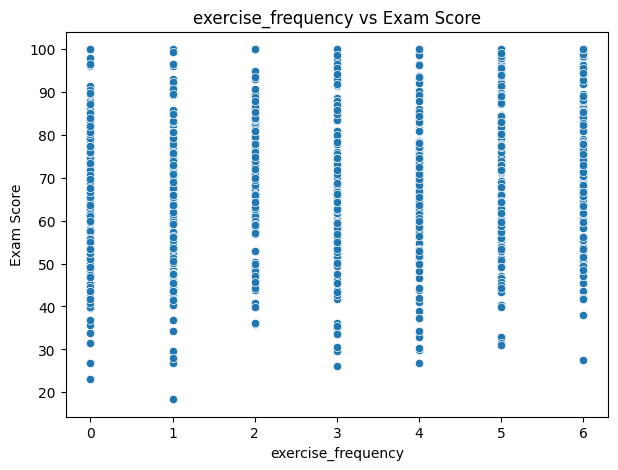

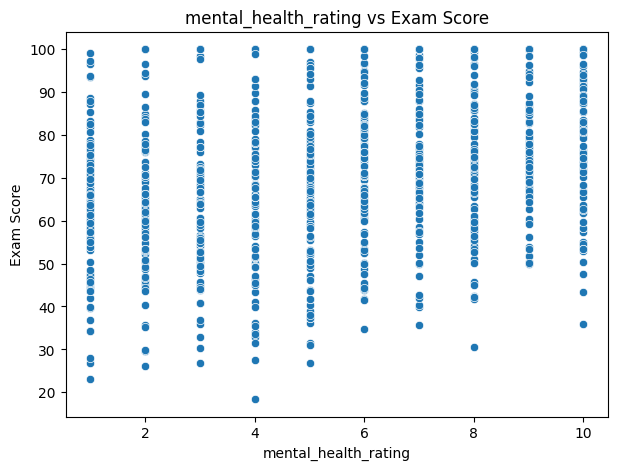

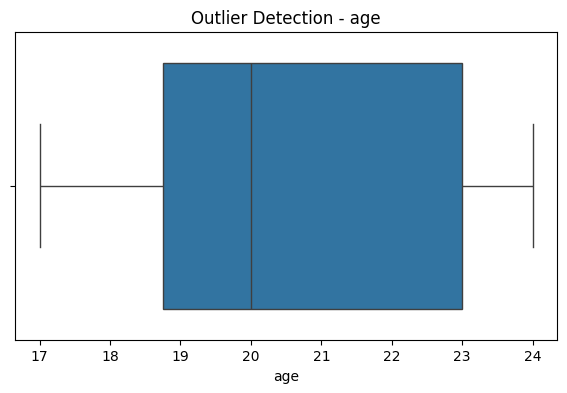

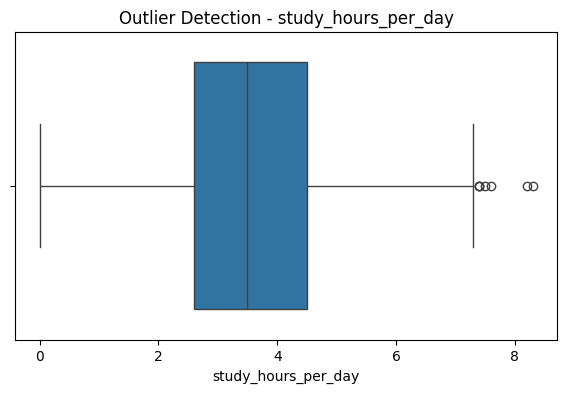

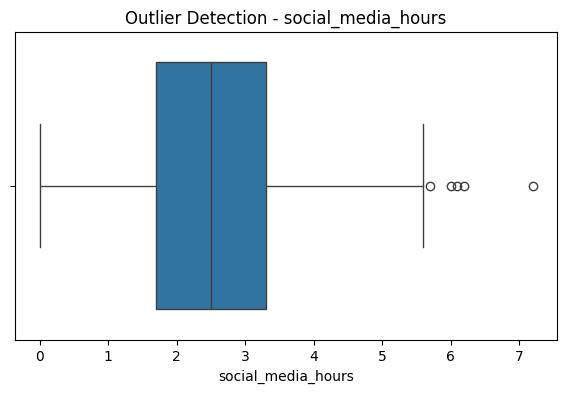

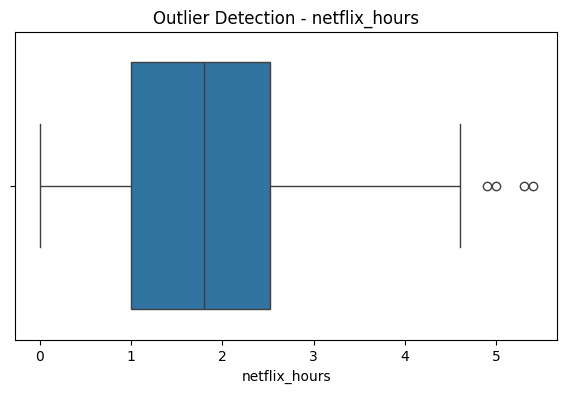

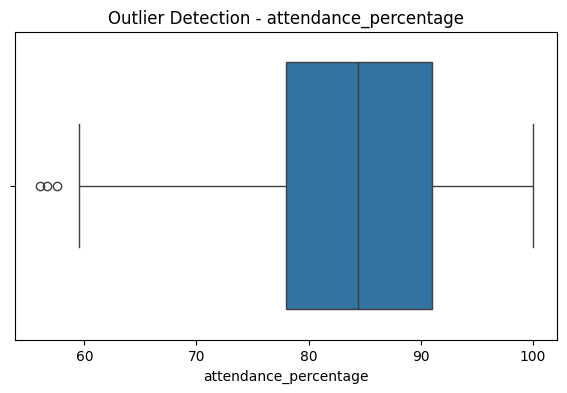

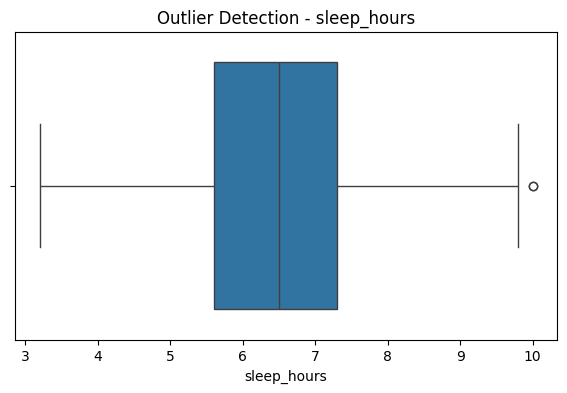

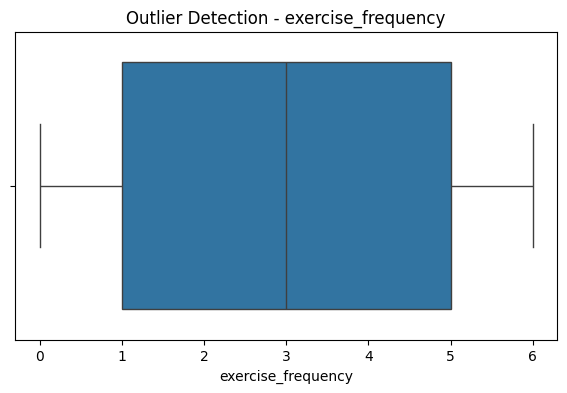

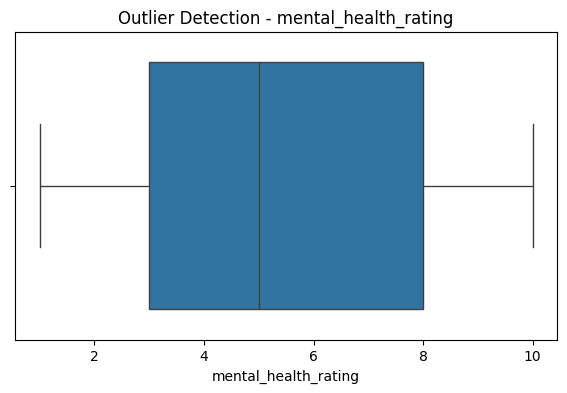

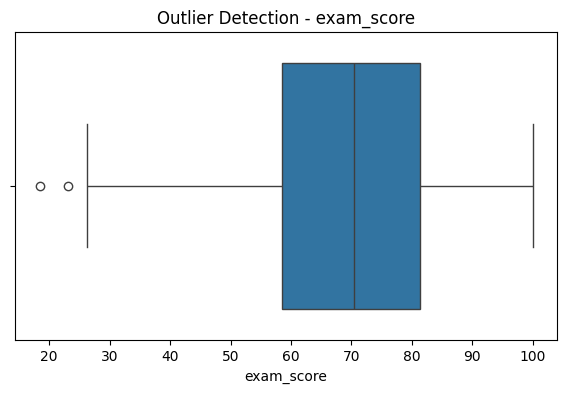


8. OUTLIER ANALYSIS
age: 0 outliers
study_hours_per_day: 7 outliers
social_media_hours: 5 outliers
netflix_hours: 4 outliers
attendance_percentage: 3 outliers
sleep_hours: 2 outliers
exercise_frequency: 0 outliers
mental_health_rating: 0 outliers
exam_score: 2 outliers

9. GROUP-WISE ANALYSIS

Average Exam Score by Gender:
gender
Female    69.74
Male      69.37
Other     70.65
Name: exam_score, dtype: float64

Average Exam Score by Part-Time Job:
part_time_job
No     69.84
Yes    68.74
Name: exam_score, dtype: float64

Average Exam Score by Diet Quality:
diet_quality
Fair    70.43
Good    69.37
Poor    68.13
Name: exam_score, dtype: float64

Average Exam Score by Internet Quality:
internet_quality
Average    70.64
Good       68.65
Poor       69.72
Name: exam_score, dtype: float64

Average Exam Score by Extracurricular Participation:
extracurricular_participation
No     69.59
Yes    69.62
Name: exam_score, dtype: float64

10. FEATURE SELECTION

Selected Features:
['age', 'gender', 'stu

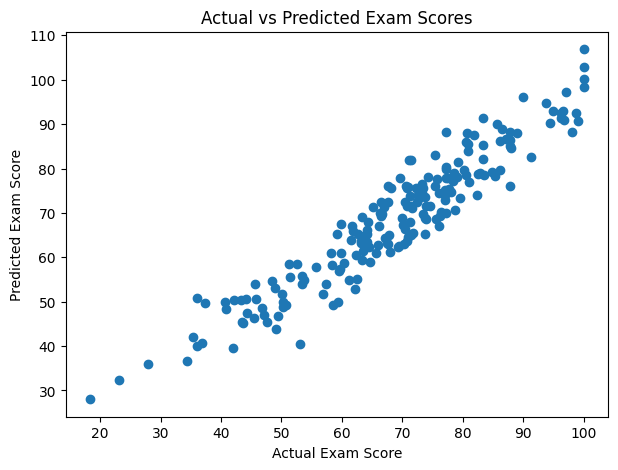


12. PASS / FAIL CLASSIFICATION

Pass = 1
Fail = 0

Pass/Fail Distribution:
pass_fail
1    869
0    131
Name: count, dtype: int64

13. CLASSIFICATION RESULTS

TRAINING PERFORMANCE
Accuracy : 0.958
Precision: 0.97
Recall   : 0.981
F1 Score : 0.976

TESTING PERFORMANCE
Accuracy : 0.955
Precision: 0.971
Recall   : 0.977
F1 Score : 0.974

Confusion Matrix:
[[ 21   5]
 [  4 170]]


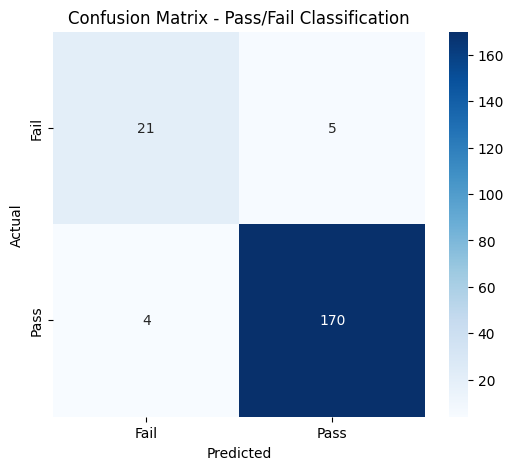


Classification Report:
              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200


14. OVERFITTING / UNDERFITTING ANALYSIS

Regression:
Training R²: 0.902
Testing R²: 0.897
R² Difference: 0.006
Conclusion: The regression model does not show a strong sign of overfitting.

Classification:
Training Accuracy: 0.958
Testing Accuracy: 0.955
Accuracy Difference: 0.003
Conclusion: The classification model does not show a strong sign of overfitting.

15. FINAL OBSERVATIONS

1. Study hours per day is the strongest numerical factor
   associated with exam score. Students who spend more time
   studying generally achieve higher exam scores.

2. Mental health rating also shows a positive relationship
   with exam performance, indicati

In [4]:
# ================================================================
# STUDENT PERFORMANCE ANALYSIS AND MACHINE LEARNING
# EDA + LINEAR REGRESSION + CLASSIFICATION
# ================================================================

# ------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------

file_path = "Day18_19_student_habits_performance (1).csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("STUDENT PERFORMANCE DATA ANALYSIS")
print("=" * 70)

print("\nDataset loaded successfully!")


# ------------------------------------------------
# 3. BASIC DATASET UNDERSTANDING
# ------------------------------------------------

print("\n" + "=" * 70)
print("1. DATASET OVERVIEW")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


# ------------------------------------------------
# 4. IDENTIFY NUMERICAL AND CATEGORICAL VARIABLES
# ------------------------------------------------

print("\n" + "=" * 70)
print("2. NUMERICAL AND CATEGORICAL VARIABLES")
print("=" * 70)

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Variables:")
print(numerical_columns)

print("\nCategorical Variables:")
print(categorical_columns)


# ------------------------------------------------
# 5. DESCRIPTIVE STATISTICS
# ------------------------------------------------

print("\n" + "=" * 70)
print("3. DESCRIPTIVE STATISTICS")
print("=" * 70)

print("\nNumerical Statistics:")
print(df.describe())

print("\nCategorical Statistics:")
print(df.describe(include="object"))


# ------------------------------------------------
# 6. CHECK MISSING VALUES
# ------------------------------------------------

print("\n" + "=" * 70)
print("4. MISSING VALUE ANALYSIS")
print("=" * 70)

missing_values = df.isnull().sum()

print("\nMissing Values:")
print(missing_values)

print("\nTotal Missing Values:")
print(missing_values.sum())


# ------------------------------------------------
# 7. CHECK DUPLICATES
# ------------------------------------------------

print("\n" + "=" * 70)
print("5. DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)


# ------------------------------------------------
# 8. TARGET VARIABLE ANALYSIS
# ------------------------------------------------

print("\n" + "=" * 70)
print("6. EXAM SCORE ANALYSIS")
print("=" * 70)

print("\nExam Score Statistics:")
print(df["exam_score"].describe())

print("\nAverage Exam Score:",
      round(df["exam_score"].mean(), 2))

print("Minimum Exam Score:",
      df["exam_score"].min())

print("Maximum Exam Score:",
      df["exam_score"].max())

print("Median Exam Score:",
      df["exam_score"].median())


# ------------------------------------------------
# 9. DISTRIBUTION OF EXAM SCORE
# ------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    df["exam_score"],
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()


# ------------------------------------------------
# 10. DISTRIBUTION OF NUMERICAL VARIABLES
# ------------------------------------------------

for column in numerical_columns:

    if column == "student_id":
        continue

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()


# ------------------------------------------------
# 11. CATEGORICAL VARIABLE ANALYSIS
# ------------------------------------------------

for column in categorical_columns:

    if column == "student_id":
        continue

    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=30)

    plt.show()


# ------------------------------------------------
# 12. CORRELATION ANALYSIS
# ------------------------------------------------

print("\n" + "=" * 70)
print("7. CORRELATION ANALYSIS")
print("=" * 70)

numeric_for_corr = df.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numeric_for_corr.corr()

print("\nCorrelation with Exam Score:")

exam_correlation = correlation_matrix[
    "exam_score"
].sort_values(ascending=False)

print(exam_correlation)


# Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


# ------------------------------------------------
# 13. RELATIONSHIPS WITH EXAM SCORE
# ------------------------------------------------

important_numeric_features = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "mental_health_rating"
]

for column in important_numeric_features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x=column,
        y="exam_score"
    )

    plt.title(f"{column} vs Exam Score")
    plt.xlabel(column)
    plt.ylabel("Exam Score")

    plt.show()


# ------------------------------------------------
# 14. BOX PLOT FOR OUTLIER DETECTION
# ------------------------------------------------

for column in numerical_columns:

    if column == "student_id":
        continue

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Outlier Detection - {column}")

    plt.show()


# ------------------------------------------------
# 15. IDENTIFY OUTLIERS USING IQR
# ------------------------------------------------

print("\n" + "=" * 70)
print("8. OUTLIER ANALYSIS")
print("=" * 70)

for column in numerical_columns:

    if column == "student_id":
        continue

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(
        f"{column}: {len(outliers)} outliers"
    )


# ------------------------------------------------
# 16. GROUP-WISE EDA
# ------------------------------------------------

print("\n" + "=" * 70)
print("9. GROUP-WISE ANALYSIS")
print("=" * 70)

print("\nAverage Exam Score by Gender:")
print(
    df.groupby("gender")["exam_score"]
      .mean()
      .round(2)
)

print("\nAverage Exam Score by Part-Time Job:")
print(
    df.groupby("part_time_job")["exam_score"]
      .mean()
      .round(2)
)

print("\nAverage Exam Score by Diet Quality:")
print(
    df.groupby("diet_quality")["exam_score"]
      .mean()
      .round(2)
)

print("\nAverage Exam Score by Internet Quality:")
print(
    df.groupby("internet_quality")["exam_score"]
      .mean()
      .round(2)
)

print("\nAverage Exam Score by Extracurricular Participation:")
print(
    df.groupby("extracurricular_participation")[
        "exam_score"
    ].mean().round(2)
)


# ------------------------------------------------
# 17. SELECT FEATURES FOR MACHINE LEARNING
# ------------------------------------------------

print("\n" + "=" * 70)
print("10. FEATURE SELECTION")
print("=" * 70)

# student_id is excluded because it is only an identifier.

features = [
    "age",
    "gender",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "part_time_job",
    "attendance_percentage",
    "sleep_hours",
    "diet_quality",
    "exercise_frequency",
    "parental_education_level",
    "internet_quality",
    "mental_health_rating",
    "extracurricular_participation"
]

X = df[features]

# Regression target
y_regression = df["exam_score"]

print("\nSelected Features:")
print(features)

print("\nRegression Target:")
print("exam_score")


# ------------------------------------------------
# 18. IDENTIFY FEATURE TYPES
# ------------------------------------------------

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ------------------------------------------------
# 19. PREPROCESSING PIPELINE
# ------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------
# 20. TRAIN-TEST SPLIT FOR REGRESSION
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))


# ------------------------------------------------
# 21. LINEAR REGRESSION MODEL
# ------------------------------------------------

linear_regression = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_regression.fit(
    X_train,
    y_train
)


# ------------------------------------------------
# 22. REGRESSION PREDICTIONS
# ------------------------------------------------

y_train_pred = linear_regression.predict(X_train)

y_test_pred = linear_regression.predict(X_test)


# ------------------------------------------------
# 23. REGRESSION EVALUATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("11. LINEAR REGRESSION RESULTS")
print("=" * 70)


# Training metrics

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(
    y_train,
    y_train_pred
)


# Testing metrics

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


print("\nTRAINING PERFORMANCE")

print("MAE :", round(train_mae, 3))
print("MSE :", round(train_mse, 3))
print("RMSE:", round(train_rmse, 3))
print("R²  :", round(train_r2, 3))


print("\nTESTING PERFORMANCE")

print("MAE :", round(test_mae, 3))
print("MSE :", round(test_mse, 3))
print("RMSE:", round(test_rmse, 3))
print("R²  :", round(test_r2, 3))


# ------------------------------------------------
# 24. ACTUAL VS PREDICTED
# ------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_test_pred
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.title(
    "Actual vs Predicted Exam Scores"
)

plt.show()


# ------------------------------------------------
# 25. CREATE PASS/FAIL CLASSIFICATION TARGET
# ------------------------------------------------

print("\n" + "=" * 70)
print("12. PASS / FAIL CLASSIFICATION")
print("=" * 70)

# Passing score = 50

df["pass_fail"] = np.where(
    df["exam_score"] >= 50,
    1,
    0
)

print("\nPass = 1")
print("Fail = 0")

print("\nPass/Fail Distribution:")

print(
    df["pass_fail"].value_counts()
)


# ------------------------------------------------
# 26. CLASSIFICATION FEATURES AND TARGET
# ------------------------------------------------

X_classification = df[features]

y_classification = df["pass_fail"]


# ------------------------------------------------
# 27. TRAIN-TEST SPLIT FOR CLASSIFICATION
# ------------------------------------------------

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)


# ------------------------------------------------
# 28. LOGISTIC REGRESSION MODEL
# ------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)


logistic_model.fit(
    X_train_c,
    y_train_c
)


# ------------------------------------------------
# 29. CLASSIFICATION PREDICTIONS
# ------------------------------------------------

y_train_class_pred = logistic_model.predict(
    X_train_c
)

y_test_class_pred = logistic_model.predict(
    X_test_c
)


# ------------------------------------------------
# 30. CLASSIFICATION EVALUATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("13. CLASSIFICATION RESULTS")
print("=" * 70)


# Training

train_accuracy = accuracy_score(
    y_train_c,
    y_train_class_pred
)

train_precision = precision_score(
    y_train_c,
    y_train_class_pred
)

train_recall = recall_score(
    y_train_c,
    y_train_class_pred
)

train_f1 = f1_score(
    y_train_c,
    y_train_class_pred
)


# Testing

test_accuracy = accuracy_score(
    y_test_c,
    y_test_class_pred
)

test_precision = precision_score(
    y_test_c,
    y_test_class_pred
)

test_recall = recall_score(
    y_test_c,
    y_test_class_pred
)

test_f1 = f1_score(
    y_test_c,
    y_test_class_pred
)


print("\nTRAINING PERFORMANCE")

print("Accuracy :", round(train_accuracy, 3))
print("Precision:", round(train_precision, 3))
print("Recall   :", round(train_recall, 3))
print("F1 Score :", round(train_f1, 3))


print("\nTESTING PERFORMANCE")

print("Accuracy :", round(test_accuracy, 3))
print("Precision:", round(test_precision, 3))
print("Recall   :", round(test_recall, 3))
print("F1 Score :", round(test_f1, 3))


# ------------------------------------------------
# 31. CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(
    y_test_c,
    y_test_class_pred
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Pass/Fail Classification"
)

plt.show()


# ------------------------------------------------
# 32. CLASSIFICATION REPORT
# ------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_c,
        y_test_class_pred,
        target_names=["Fail", "Pass"]
    )
)


# ------------------------------------------------
# 33. OVERFITTING / UNDERFITTING CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("14. OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 70)

print("\nRegression:")

print(
    "Training R²:",
    round(train_r2, 3)
)

print(
    "Testing R²:",
    round(test_r2, 3)
)

r2_difference = abs(
    train_r2 - test_r2
)

print(
    "R² Difference:",
    round(r2_difference, 3)
)

if r2_difference < 0.05:
    print(
        "Conclusion: The regression model does not show "
        "a strong sign of overfitting."
    )
elif train_r2 > test_r2:
    print(
        "Conclusion: The model may have some overfitting."
    )
else:
    print(
        "Conclusion: Further investigation is required."
    )


print("\nClassification:")

print(
    "Training Accuracy:",
    round(train_accuracy, 3)
)

print(
    "Testing Accuracy:",
    round(test_accuracy, 3)
)

accuracy_difference = abs(
    train_accuracy - test_accuracy
)

print(
    "Accuracy Difference:",
    round(accuracy_difference, 3)
)

if accuracy_difference < 0.05:
    print(
        "Conclusion: The classification model does not "
        "show a strong sign of overfitting."
    )
else:
    print(
        "Conclusion: The classification model may "
        "have some overfitting."
    )


# ------------------------------------------------
# 34. FINAL OBSERVATIONS
# ------------------------------------------------

print("\n" + "=" * 70)
print("15. FINAL OBSERVATIONS")
print("=" * 70)

print("""
1. Study hours per day is the strongest numerical factor
   associated with exam score. Students who spend more time
   studying generally achieve higher exam scores.

2. Mental health rating also shows a positive relationship
   with exam performance, indicating that student well-being
   may be associated with academic performance.

3. Social media hours and Netflix hours show negative
   relationships with exam score. Higher entertainment/social
   media usage is generally associated with lower scores.

4. Exercise frequency and sleep hours have positive but
   relatively weaker relationships with exam score compared
   with study hours.

5. The Linear Regression model provides strong predictive
   performance when the selected academic, lifestyle, and
   demographic features are combined.

6. The Pass/Fail Logistic Regression model performs strongly,
   indicating that the selected student characteristics contain
   useful information for identifying whether a student is likely
   to pass.

7. The training and testing performance are relatively close,
   suggesting that the models generalize reasonably well and
   there is no major evidence of overfitting.

8. Missing values are present in parental_education_level,
   so categorical imputation is required before machine
   learning. Other variables contain complete observations.
""")


# ------------------------------------------------
# 35. END
# ------------------------------------------------

print("\n" + "=" * 70)
print("MACHINE LEARNING WORKFLOW COMPLETED")
print("=" * 70)